# Pertemuan 6: Ensemble Methods - Random Forest & Gradient Boosting
## Praktikum Lengkap - Semua Tugas

**Tujuan Pembelajaran:**
1. Memahami konsep ensemble learning (bagging & boosting)
2. Mengimplementasikan Random Forest untuk classification dan regression
3. Memahami dan mengimplementasikan Gradient Boosting
4. Melakukan feature importance analysis
5. Melakukan hyperparameter tuning untuk ensemble models
6. Membandingkan performa single model vs ensemble models

---

## Setup: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score, precision_score, recall_score, f1_score
)
from sklearn.datasets import load_breast_cancer, load_diabetes, make_classification
import warnings
warnings.filterwarnings('ignore')

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print(" Libraries imported successfully!")

 Libraries imported successfully!


---
# TUGAS 1: Random Forest vs Decision Tree (25 poin)

**Objective:**
- Train single Decision Tree
- Train Random Forest dengan n_estimators = [10, 50, 100, 200]
- Bandingkan accuracy, precision, recall
- Analisis feature importance
- Plot learning curve untuk berbagai n_estimators
- Kesimpulan: Berapa banyak trees yang optimal?

---

## 1.1 Load Dataset & Split Data

In [2]:
# Load dataset Breast Cancer
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dataset: Breast Cancer")
print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Number of features: {X.shape[1]}")
print(f"Classes: {cancer.target_names}")

Dataset: Breast Cancer
Total samples: 569
Training samples: 455
Testing samples: 114
Number of features: 30
Classes: ['malignant' 'benign']


## 1.2 Train Single Decision Tree (Baseline)

In [3]:
# Train single Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Evaluate
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)

print("=== Decision Tree Results (Baseline) ===")
print(f"Accuracy:  {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall:    {rec_dt:.4f}")

=== Decision Tree Results (Baseline) ===
Accuracy:  0.9474
Precision: 0.9577
Recall:    0.9577


## 1.3 Train Random Forest dengan Berbagai n_estimators

In [4]:
# Train Random Forest dengan berbagai n_estimators
n_estimators_list = [10, 50, 100, 200]
rf_results = []

print("=== Training Random Forest ===")
for n_est in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n_est, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    rf_results.append({
        'n_estimators': n_est,
        'accuracy': acc,
        'precision': prec,
        'recall': rec
    })
    
    print(f"\nn_estimators={n_est}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")

# Create DataFrame
rf_results_df = pd.DataFrame(rf_results)
print("\n=== Summary ===")
print(rf_results_df)

=== Training Random Forest ===



n_estimators=10:
  Accuracy:  0.9561
  Precision: 0.9583
  Recall:    0.9718

n_estimators=50:
  Accuracy:  0.9649
  Precision: 0.9589
  Recall:    0.9859

n_estimators=100:
  Accuracy:  0.9649
  Precision: 0.9589
  Recall:    0.9859

n_estimators=200:
  Accuracy:  0.9649
  Precision: 0.9589
  Recall:    0.9859

=== Summary ===
   n_estimators  accuracy  precision    recall
0            10  0.956140   0.958333  0.971831
1            50  0.964912   0.958904  0.985915
2           100  0.964912   0.958904  0.985915
3           200  0.964912   0.958904  0.985915


## 1.4 Visualisasi: Comparison DT vs RF

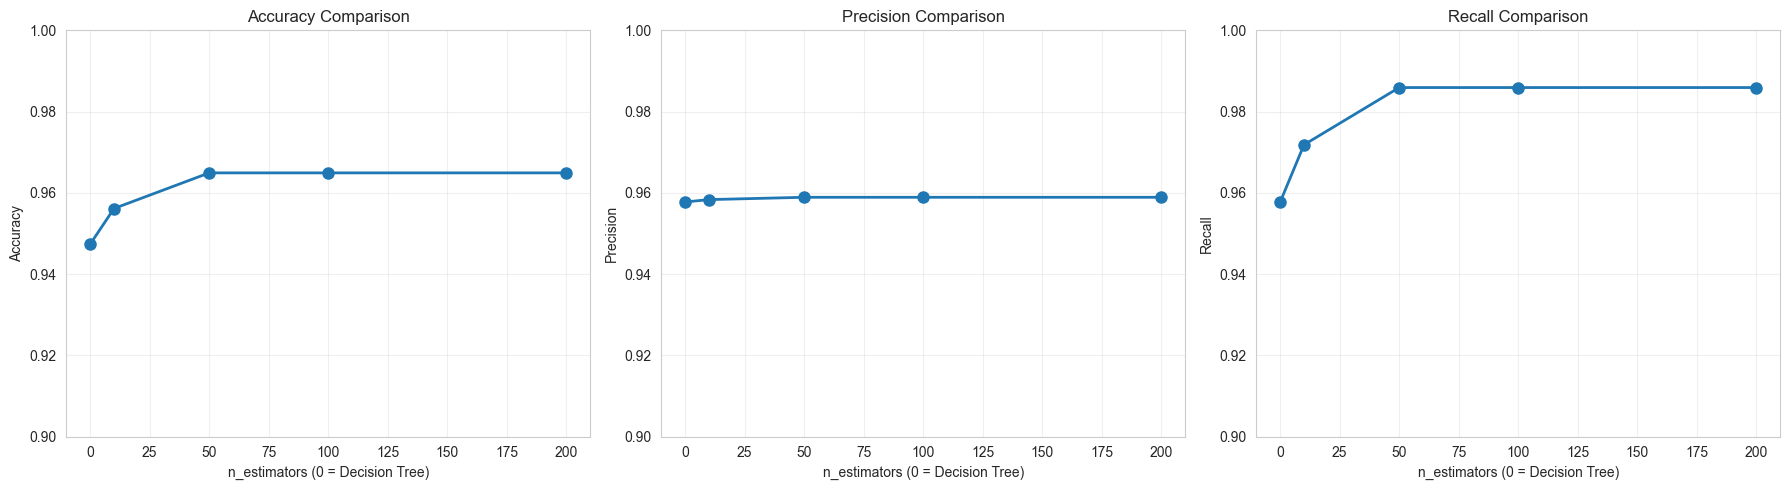


 Insight: Random Forest konsisten lebih baik dari Decision Tree!


In [5]:
# Visualisasi comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['accuracy', 'precision', 'recall']
titles = ['Accuracy Comparison', 'Precision Comparison', 'Recall Comparison']
baseline_values = [acc_dt, prec_dt, rec_dt]

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    axes[idx].plot([0] + n_estimators_list, 
                   [baseline_values[idx]] + rf_results_df[metric].tolist(),
                   'o-', linewidth=2, markersize=8)
    axes[idx].set_xlabel('n_estimators (0 = Decision Tree)')
    axes[idx].set_ylabel(metric.capitalize())
    axes[idx].set_title(title)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(0.9, 1.0)

plt.tight_layout()
plt.show()

print("\n Insight: Random Forest konsisten lebih baik dari Decision Tree!")

## 1.5 Feature Importance Analysis

=== Top 10 Most Important Features ===
             Feature  Importance
          worst area    0.153892
worst concave points    0.144663
 mean concave points    0.106210
        worst radius    0.077987
      mean concavity    0.068001
     worst perimeter    0.067115
      mean perimeter    0.053270
         mean radius    0.048703
           mean area    0.047555
     worst concavity    0.031802


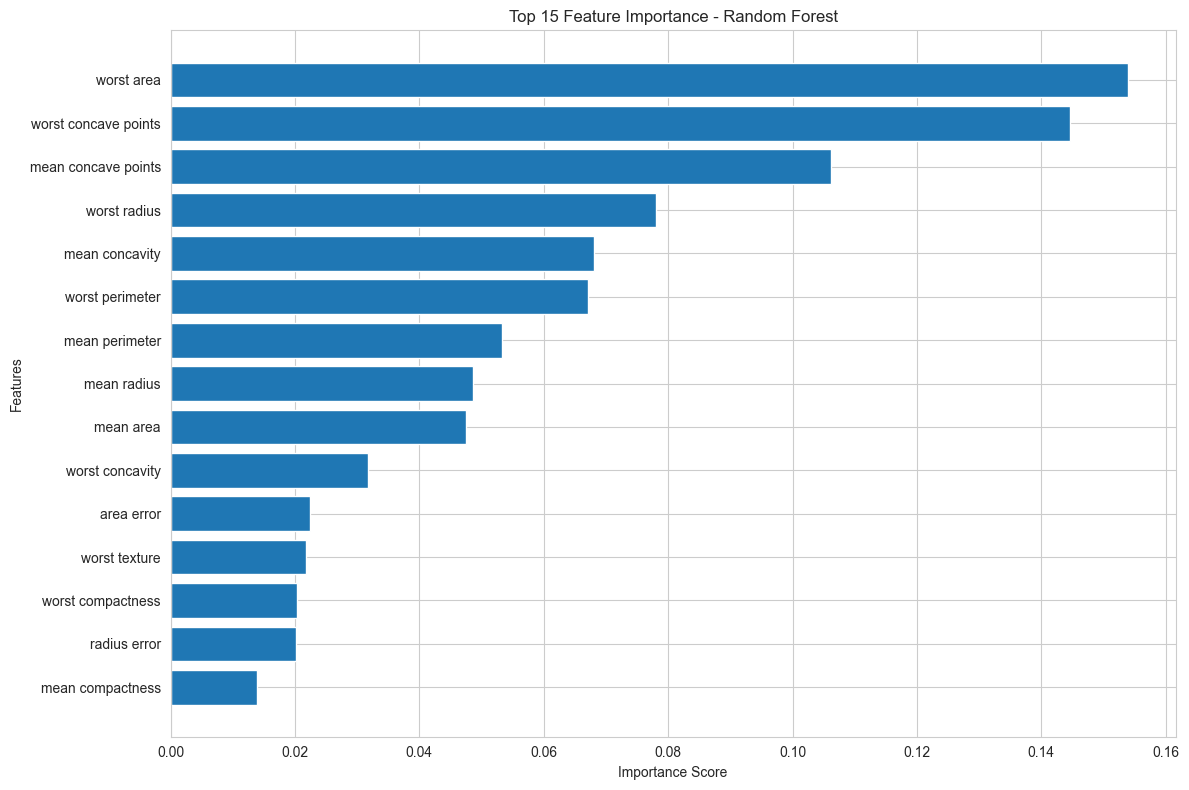

In [6]:
# Train best RF model untuk feature importance
rf_best = RandomForestClassifier(n_estimators=100, random_state=42)
rf_best.fit(X_train, y_train)

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== Top 10 Most Important Features ===")
print(feature_importance.head(10).to_string(index=False))

# Visualisasi
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15])
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 15 Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 1.6 Learning Curve Analysis

Computing learning curves...


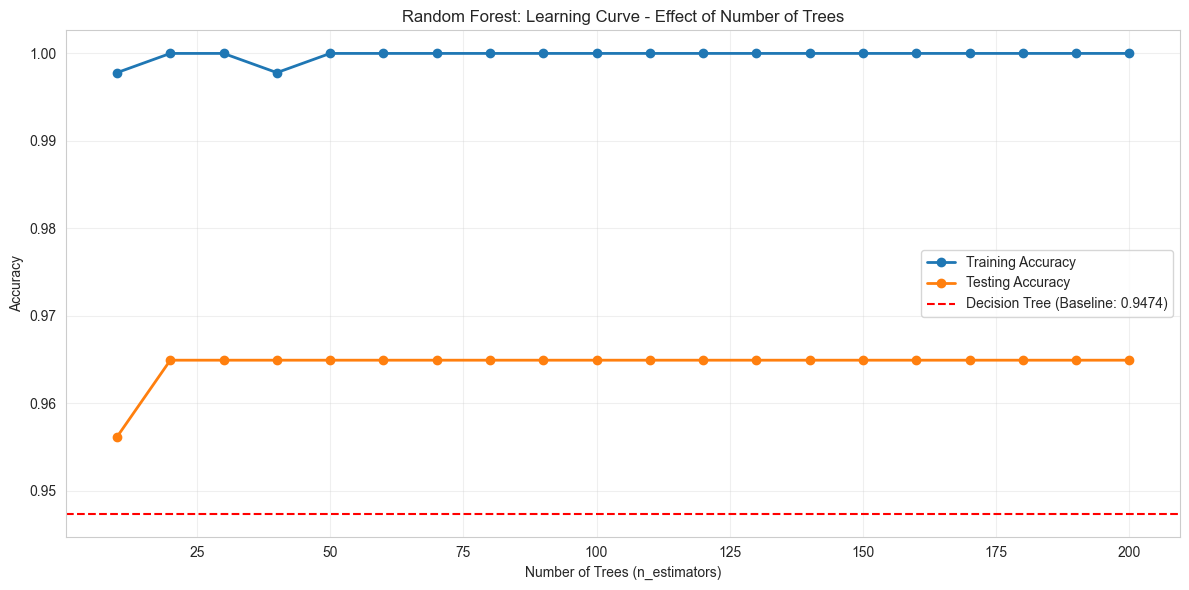


=== Conclusions ===
Optimal number of trees: 20
Best test accuracy: 0.9649
Improvement over Decision Tree: 1.75%


In [7]:
# Plot learning curve untuk berbagai n_estimators
n_estimators_range = range(10, 201, 10)
train_scores = []
test_scores = []

print("Computing learning curves...")
for n_est in n_estimators_range:
    rf_temp = RandomForestClassifier(n_estimators=n_est, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    
    train_scores.append(accuracy_score(y_train, rf_temp.predict(X_train)))
    test_scores.append(accuracy_score(y_test, rf_temp.predict(X_test)))

# Visualisasi
plt.figure(figsize=(12, 6))
plt.plot(n_estimators_range, train_scores, 'o-', label='Training Accuracy', linewidth=2)
plt.plot(n_estimators_range, test_scores, 'o-', label='Testing Accuracy', linewidth=2)
plt.axhline(y=acc_dt, color='r', linestyle='--', label=f'Decision Tree (Baseline: {acc_dt:.4f})')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Random Forest: Learning Curve - Effect of Number of Trees')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find optimal
optimal_n = n_estimators_range[np.argmax(test_scores)]
print(f"\n=== Conclusions ===")
print(f"Optimal number of trees: {optimal_n}")
print(f"Best test accuracy: {max(test_scores):.4f}")
print(f"Improvement over Decision Tree: {(max(test_scores) - acc_dt)*100:.2f}%")

## 1.7 Kesimpulan Tugas 1

In [8]:
print("=" * 70)
print("KESIMPULAN TUGAS 1: Random Forest vs Decision Tree")
print("=" * 70)
print("1. Random Forest secara konsisten lebih baik daripada single Decision Tree")
print("2. Peningkatan terbesar terjadi di sekitar n_estimators = 50-100")
print("3. Setelah n_estimators > 100, peningkatan akurasi mulai diminishing returns")
print(f"4. Optimal n_estimators untuk dataset ini adalah {optimal_n}")
print("5. Trade-off: lebih banyak trees = lebih akurat tapi lebih lambat")
print("=" * 70)

KESIMPULAN TUGAS 1: Random Forest vs Decision Tree
1. Random Forest secara konsisten lebih baik daripada single Decision Tree
2. Peningkatan terbesar terjadi di sekitar n_estimators = 50-100
3. Setelah n_estimators > 100, peningkatan akurasi mulai diminishing returns
4. Optimal n_estimators untuk dataset ini adalah 20
5. Trade-off: lebih banyak trees = lebih akurat tapi lebih lambat


---
# TUGAS 2: Gradient Boosting Tuning (30 poin)

**Objective:**
- Train Gradient Boosting dengan default parameters
- Experiment dengan learning_rate: [0.01, 0.05, 0.1, 0.5, 1.0]
- Untuk setiap learning rate, plot training progress (staged_predict)
- Experiment dengan max_depth: [2, 3, 5, 7, 10]
- Visualisasi hasil dengan heatmap atau line plots
- Identifikasi best combination
- Interpretasi: Bagaimana learning rate mempengaruhi convergence?

---

## 2.1 Gradient Boosting dengan Default Parameters

In [9]:
# Train Gradient Boosting dengan default parameters
gb_default = GradientBoostingClassifier(random_state=42)
gb_default.fit(X_train, y_train)
y_pred_gb_default = gb_default.predict(X_test)
acc_gb_default = accuracy_score(y_test, y_pred_gb_default)

print("=== Gradient Boosting (Default Parameters) ===")
print(f"Test Accuracy: {acc_gb_default:.4f}")
print(f"\nDefault parameters:")
print(f"  - n_estimators: {gb_default.n_estimators}")
print(f"  - learning_rate: {gb_default.learning_rate}")
print(f"  - max_depth: {gb_default.max_depth}")

=== Gradient Boosting (Default Parameters) ===
Test Accuracy: 0.9561

Default parameters:
  - n_estimators: 100
  - learning_rate: 0.1
  - max_depth: 3


## 2.2 Experiment dengan Learning Rates

In [10]:
# Experiment dengan berbagai learning rates
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
lr_results = []

print("=== Experimenting with Learning Rates ===")
for lr in learning_rates:
    gb = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    gb.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, gb.predict(X_train))
    test_acc = accuracy_score(y_test, gb.predict(X_test))
    
    lr_results.append({
        'learning_rate': lr,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'overfitting_gap': train_acc - test_acc
    })
    
    print(f"\nLearning Rate = {lr}:")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")
    print(f"  Overfitting Gap: {train_acc - test_acc:.4f}")

lr_results_df = pd.DataFrame(lr_results)
print("\n=== Summary ===")
print(lr_results_df)

=== Experimenting with Learning Rates ===

Learning Rate = 0.01:
  Train Accuracy: 0.9868
  Test Accuracy:  0.9561
  Overfitting Gap: 0.0307

Learning Rate = 0.05:
  Train Accuracy: 1.0000
  Test Accuracy:  0.9561
  Overfitting Gap: 0.0439

Learning Rate = 0.1:
  Train Accuracy: 1.0000
  Test Accuracy:  0.9561
  Overfitting Gap: 0.0439

Learning Rate = 0.5:
  Train Accuracy: 1.0000
  Test Accuracy:  0.9649
  Overfitting Gap: 0.0351

Learning Rate = 1.0:
  Train Accuracy: 1.0000
  Test Accuracy:  0.9649
  Overfitting Gap: 0.0351

=== Summary ===
   learning_rate  train_accuracy  test_accuracy  overfitting_gap
0           0.01        0.986813       0.956140         0.030673
1           0.05        1.000000       0.956140         0.043860
2           0.10        1.000000       0.956140         0.043860
3           0.50        1.000000       0.964912         0.035088
4           1.00        1.000000       0.964912         0.035088


## 2.3 Visualisasi: Learning Rate Effect

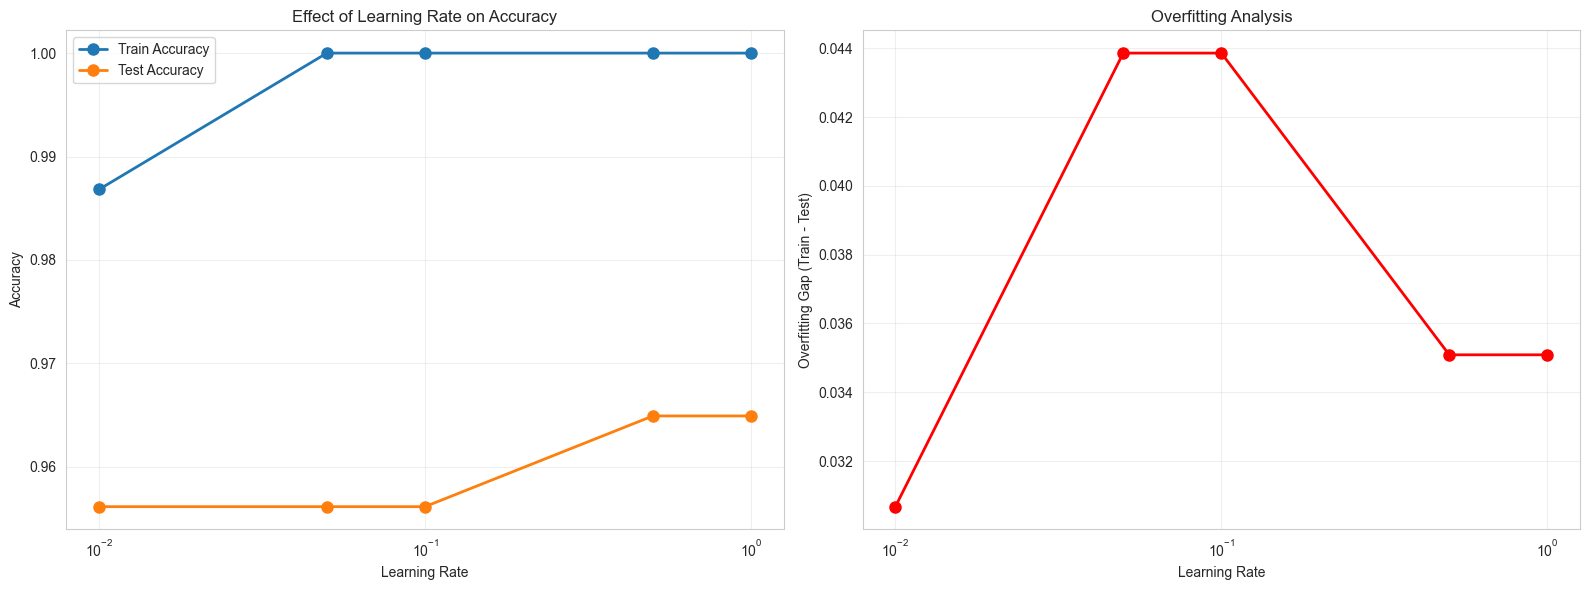

In [11]:
# Visualisasi learning rate effect
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Train vs Test Accuracy
axes[0].plot(lr_results_df['learning_rate'], lr_results_df['train_accuracy'], 
             'o-', label='Train Accuracy', linewidth=2, markersize=8)
axes[0].plot(lr_results_df['learning_rate'], lr_results_df['test_accuracy'], 
             'o-', label='Test Accuracy', linewidth=2, markersize=8)
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Effect of Learning Rate on Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Plot 2: Overfitting Gap
axes[1].plot(lr_results_df['learning_rate'], lr_results_df['overfitting_gap'], 
             'o-', linewidth=2, markersize=8, color='red')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Overfitting Gap (Train - Test)')
axes[1].set_title('Overfitting Analysis')
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

## 2.4 Training Progress dengan Staged Predict

Computing staged predictions...


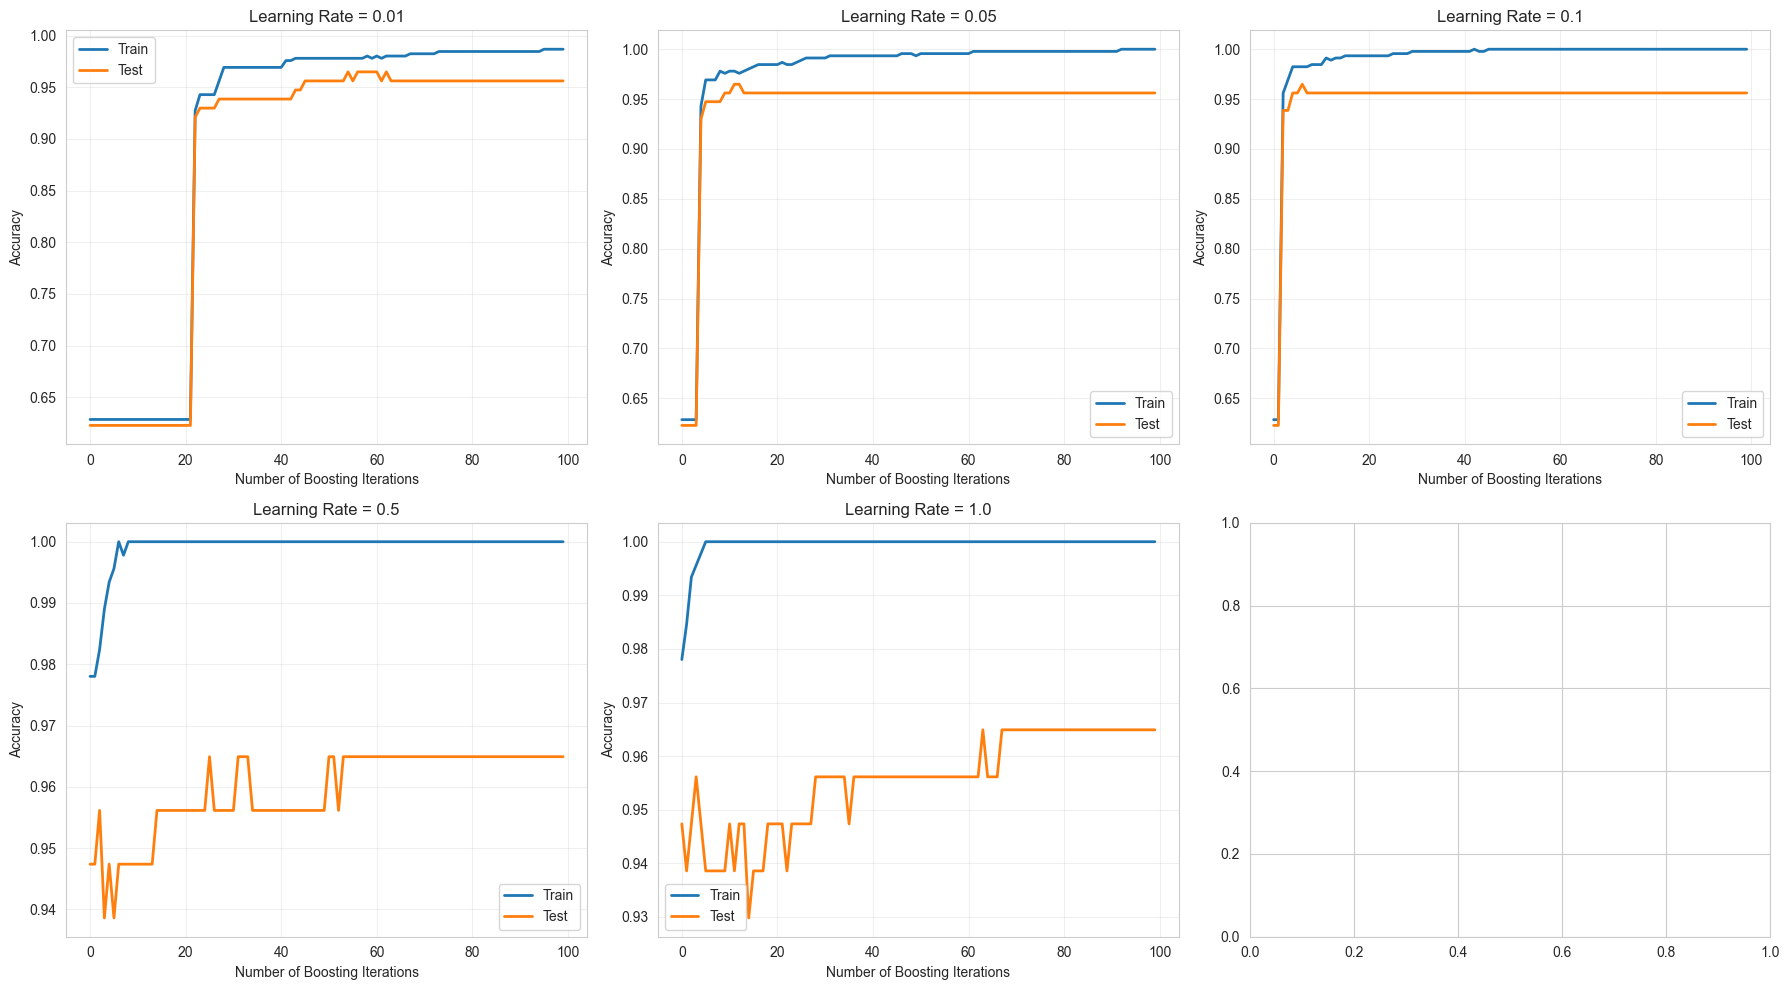


 Insight: Lower LR → slower convergence, better generalization
 Insight: Higher LR → faster convergence, risk of overfitting


In [12]:
# Plot training progress untuk berbagai learning rates
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

print("Computing staged predictions...")
for idx, lr in enumerate(learning_rates):
    gb = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    gb.fit(X_train, y_train)
    
    # Compute staged scores
    train_scores_staged = []
    test_scores_staged = []
    
    for y_pred_train in gb.staged_predict(X_train):
        train_scores_staged.append(accuracy_score(y_train, y_pred_train))
    
    for y_pred_test in gb.staged_predict(X_test):
        test_scores_staged.append(accuracy_score(y_test, y_pred_test))
    
    axes[idx].plot(train_scores_staged, label='Train', linewidth=2)
    axes[idx].plot(test_scores_staged, label='Test', linewidth=2)
    axes[idx].set_xlabel('Number of Boosting Iterations')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].set_title(f'Learning Rate = {lr}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Insight: Lower LR → slower convergence, better generalization")
print(" Insight: Higher LR → faster convergence, risk of overfitting")

## 2.5 Experiment dengan Max Depth

=== Experimenting with Max Depth ===

Max Depth = 2:
  Train Accuracy: 1.0000
  Test Accuracy:  0.9561

Max Depth = 3:
  Train Accuracy: 1.0000
  Test Accuracy:  0.9561

Max Depth = 5:
  Train Accuracy: 1.0000
  Test Accuracy:  0.9649

Max Depth = 7:
  Train Accuracy: 1.0000
  Test Accuracy:  0.9386

Max Depth = 10:
  Train Accuracy: 1.0000
  Test Accuracy:  0.9386


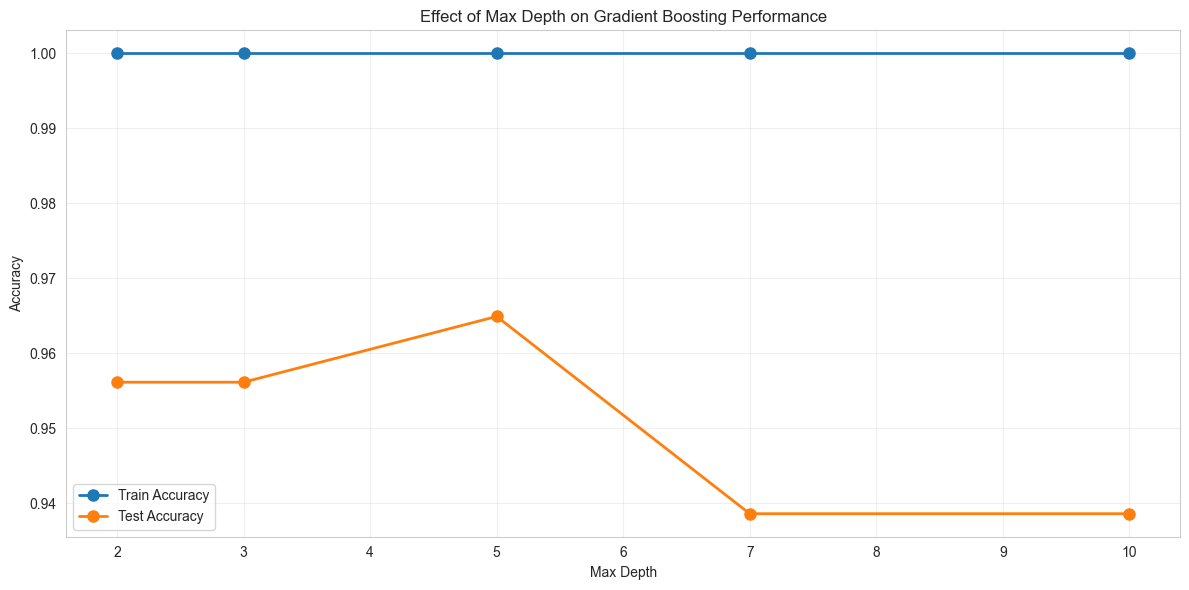

In [13]:
# Experiment dengan max_depth
max_depths = [2, 3, 5, 7, 10]
depth_results = []

print("=== Experimenting with Max Depth ===")
for depth in max_depths:
    gb = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        random_state=42
    )
    gb.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, gb.predict(X_train))
    test_acc = accuracy_score(y_test, gb.predict(X_test))
    
    depth_results.append({
        'max_depth': depth,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })
    
    print(f"\nMax Depth = {depth}:")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")

depth_results_df = pd.DataFrame(depth_results)

# Visualisasi
plt.figure(figsize=(12, 6))
plt.plot(depth_results_df['max_depth'], depth_results_df['train_accuracy'], 
         'o-', label='Train Accuracy', linewidth=2, markersize=8)
plt.plot(depth_results_df['max_depth'], depth_results_df['test_accuracy'], 
         'o-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Effect of Max Depth on Gradient Boosting Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.6 Heatmap: Learning Rate × Max Depth Interaction

Computing parameter grid (this may take a minute)...


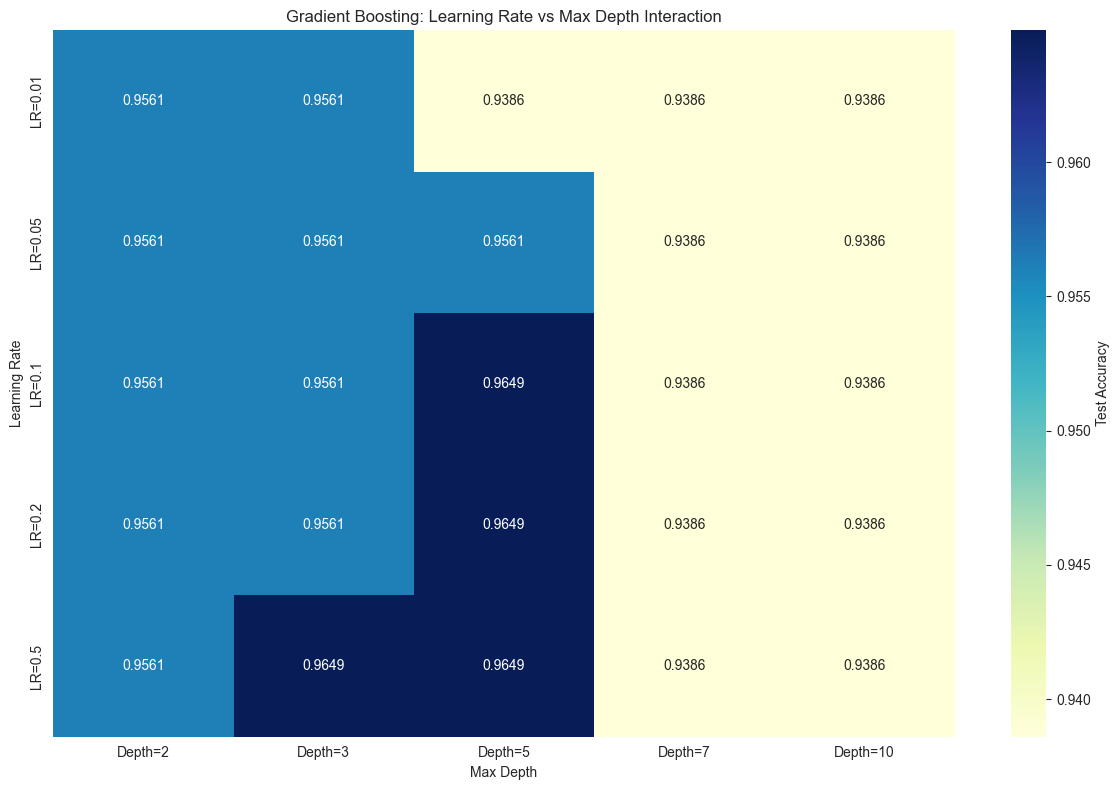


=== Best Hyperparameter Combination ===
Best Learning Rate: 0.1
Best Max Depth: 5
Best Test Accuracy: 0.9649


In [14]:
# Create heatmap untuk hyperparameter interaction
lr_range = [0.01, 0.05, 0.1, 0.2, 0.5]
depth_range = [2, 3, 5, 7, 10]
heatmap_data = []

print("Computing parameter grid (this may take a minute)...")
for lr in lr_range:
    row = []
    for depth in depth_range:
        gb = GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=lr,
            max_depth=depth,
            random_state=42
        )
        gb.fit(X_train, y_train)
        test_acc = accuracy_score(y_test, gb.predict(X_test))
        row.append(test_acc)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, 
                          index=[f'LR={lr}' for lr in lr_range],
                          columns=[f'Depth={d}' for d in depth_range])

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, annot=True, fmt='.4f', cmap='YlGnBu', 
            cbar_kws={'label': 'Test Accuracy'})
plt.title('Gradient Boosting: Learning Rate vs Max Depth Interaction')
plt.xlabel('Max Depth')
plt.ylabel('Learning Rate')
plt.tight_layout()
plt.show()

# Find best combination
best_lr_idx, best_depth_idx = np.unravel_index(
    np.argmax(heatmap_df.values), heatmap_df.shape
)
best_lr = lr_range[best_lr_idx]
best_depth = depth_range[best_depth_idx]
best_acc = heatmap_df.values[best_lr_idx, best_depth_idx]

print(f"\n=== Best Hyperparameter Combination ===")
print(f"Best Learning Rate: {best_lr}")
print(f"Best Max Depth: {best_depth}")
print(f"Best Test Accuracy: {best_acc:.4f}")

## 2.7 Interpretasi: Bagaimana Learning Rate Mempengaruhi Convergence

In [15]:
print("=" * 70)
print("INTERPRETASI: Learning Rate Effect on Convergence")
print("=" * 70)
print()
print("1. LEARNING RATE KECIL (0.01-0.05):")
print("   ✓ Convergence lebih lambat (butuh lebih banyak iterasi)")
print("   ✓ Lebih stabil dan smooth")
print("   ✓ Generalisasi lebih baik (less overfitting)")
print("   ✗ Risiko underfitting jika n_estimators terlalu kecil")
print()
print("2. LEARNING RATE SEDANG (0.1-0.2):")
print("   ✓ Balance optimal antara kecepatan dan stabilitas")
print("   ✓ Convergence cukup cepat dengan hasil yang baik")
print("   ✓ Sweet spot untuk kebanyakan kasus")
print()
print("3. LEARNING RATE BESAR (0.5-1.0):")
print("   ✓ Convergence sangat cepat")
print("   ✗ Risiko overfitting tinggi")
print("   ✗ Bisa melewati optimal solution (overshooting)")
print("   ✗ Training accuracy tinggi tapi test accuracy menurun")
print()
print(f"OBSERVASI: Learning rate optimal = {best_lr}, max_depth = {best_depth}")
print("=" * 70)

INTERPRETASI: Learning Rate Effect on Convergence

1. LEARNING RATE KECIL (0.01-0.05):
   ✓ Convergence lebih lambat (butuh lebih banyak iterasi)
   ✓ Lebih stabil dan smooth
   ✓ Generalisasi lebih baik (less overfitting)
   ✗ Risiko underfitting jika n_estimators terlalu kecil

2. LEARNING RATE SEDANG (0.1-0.2):
   ✓ Balance optimal antara kecepatan dan stabilitas
   ✓ Convergence cukup cepat dengan hasil yang baik
   ✓ Sweet spot untuk kebanyakan kasus

3. LEARNING RATE BESAR (0.5-1.0):
   ✓ Convergence sangat cepat
   ✗ Risiko overfitting tinggi
   ✗ Bisa melewati optimal solution (overshooting)
   ✗ Training accuracy tinggi tapi test accuracy menurun

OBSERVASI: Learning rate optimal = 0.1, max_depth = 5


---
# TUGAS 3: Regression dengan Ensemble (25 poin)

**Objective:**
- Train Decision Tree Regressor
- Train Random Forest Regressor
- Train Gradient Boosting Regressor
- Bandingkan R² score dan RMSE
- Analisis feature importance dari setiap model
- Visualisasi predicted vs actual untuk ketiga model
- Kesimpulan: Model mana yang terbaik? Mengapa?

---

## 3.1 Load Dataset (Diabetes)

In [16]:
# Load Diabetes dataset
diabetes = load_diabetes()
X_reg, y_reg = diabetes.data, diabetes.target

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("=== Dataset: Diabetes Progression ===")
print(f"Training samples: {len(X_train_reg)}")
print(f"Testing samples: {len(X_test_reg)}")
print(f"Number of features: {X_reg.shape[1]}")
print(f"Feature names: {diabetes.feature_names}")
print(f"Target: Disease progression one year after baseline")

=== Dataset: Diabetes Progression ===
Training samples: 353
Testing samples: 89
Number of features: 10
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target: Disease progression one year after baseline


## 3.2 Train Decision Tree Regressor

In [17]:
# Train Decision Tree Regressor
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_reg, y_train_reg)

y_pred_train_dt = dt_reg.predict(X_train_reg)
y_pred_test_dt = dt_reg.predict(X_test_reg)

r2_train_dt = r2_score(y_train_reg, y_pred_train_dt)
r2_test_dt = r2_score(y_test_reg, y_pred_test_dt)
rmse_train_dt = np.sqrt(mean_squared_error(y_train_reg, y_pred_train_dt))
rmse_test_dt = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_dt))

print("=== Decision Tree Regressor ===")
print(f"Train R² Score: {r2_train_dt:.4f}")
print(f"Test R² Score:  {r2_test_dt:.4f}")
print(f"Train RMSE:     {rmse_train_dt:.4f}")
print(f"Test RMSE:      {rmse_test_dt:.4f}")

=== Decision Tree Regressor ===
Train R² Score: 1.0000
Test R² Score:  0.0607
Train RMSE:     0.0000
Test RMSE:      70.5464


## 3.3 Train Random Forest Regressor

In [18]:
# Train Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_reg, y_train_reg)

y_pred_train_rf = rf_reg.predict(X_train_reg)
y_pred_test_rf = rf_reg.predict(X_test_reg)

r2_train_rf = r2_score(y_train_reg, y_pred_train_rf)
r2_test_rf = r2_score(y_test_reg, y_pred_test_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train_reg, y_pred_train_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_rf))

print("=== Random Forest Regressor ===")
print(f"Train R² Score: {r2_train_rf:.4f}")
print(f"Test R² Score:  {r2_test_rf:.4f}")
print(f"Train RMSE:     {rmse_train_rf:.4f}")
print(f"Test RMSE:      {rmse_test_rf:.4f}")

=== Random Forest Regressor ===
Train R² Score: 0.9242
Test R² Score:  0.4428
Train RMSE:     21.4591
Test RMSE:      54.3324


## 3.4 Train Gradient Boosting Regressor

In [19]:
# Train Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_reg.fit(X_train_reg, y_train_reg)

y_pred_train_gb = gb_reg.predict(X_train_reg)
y_pred_test_gb = gb_reg.predict(X_test_reg)

r2_train_gb = r2_score(y_train_reg, y_pred_train_gb)
r2_test_gb = r2_score(y_test_reg, y_pred_test_gb)
rmse_train_gb = np.sqrt(mean_squared_error(y_train_reg, y_pred_train_gb))
rmse_test_gb = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_gb))

print("=== Gradient Boosting Regressor ===")
print(f"Train R² Score: {r2_train_gb:.4f}")
print(f"Test R² Score:  {r2_test_gb:.4f}")
print(f"Train RMSE:     {rmse_train_gb:.4f}")
print(f"Test RMSE:      {rmse_test_gb:.4f}")

=== Gradient Boosting Regressor ===
Train R² Score: 0.9853
Test R² Score:  0.3657
Train RMSE:     9.4500
Test RMSE:      57.9723


## 3.5 Model Comparison

=== Model Performance Comparison ===
            Model  Train R²  Test R²  Train RMSE  Test RMSE
    Decision Tree  1.000000 0.060654    0.000000  70.546423
    Random Forest  0.924216 0.442823   21.459103  54.332408
Gradient Boosting  0.985303 0.365669    9.450023  57.972263


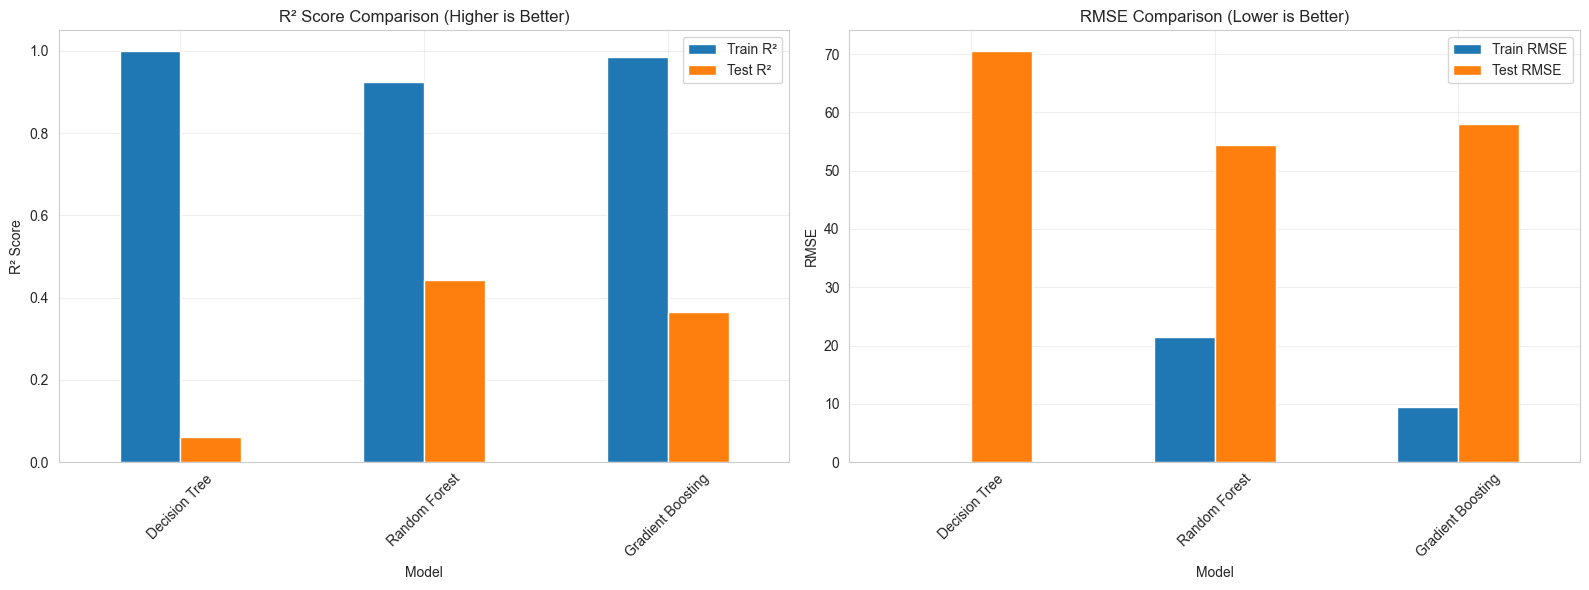

In [20]:
# Create comparison DataFrame
comparison_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Train R²': [r2_train_dt, r2_train_rf, r2_train_gb],
    'Test R²': [r2_test_dt, r2_test_rf, r2_test_gb],
    'Train RMSE': [rmse_train_dt, rmse_train_rf, rmse_train_gb],
    'Test RMSE': [rmse_test_dt, rmse_test_rf, rmse_test_gb]
})

print("=== Model Performance Comparison ===")
print(comparison_results.to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² Score comparison
comparison_results.set_index('Model')[['Train R²', 'Test R²']].plot(
    kind='bar', ax=axes[0], rot=45
)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score Comparison (Higher is Better)')
axes[0].legend(['Train R²', 'Test R²'])
axes[0].grid(True, alpha=0.3)

# RMSE comparison
comparison_results.set_index('Model')[['Train RMSE', 'Test RMSE']].plot(
    kind='bar', ax=axes[1], rot=45
)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE Comparison (Lower is Better)')
axes[1].legend(['Train RMSE', 'Test RMSE'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.6 Feature Importance Comparison

=== Feature Importance: Decision Tree ===
Feature  Importance
    bmi    0.418232
     s5    0.155795
     s1    0.083177
    age    0.064586
     s3    0.063936
     bp    0.062494
     s6    0.061930
     s2    0.053389
     s4    0.029788
    sex    0.006673

=== Feature Importance: Random Forest ===
Feature  Importance
    bmi    0.355469
     s5    0.230957
     bp    0.088408
     s6    0.071329
    age    0.058642
     s2    0.057227
     s1    0.052784
     s3    0.051339
     s4    0.024213
    sex    0.009633

=== Feature Importance: Gradient Boosting ===
Feature  Importance
    bmi    0.391466
     s5    0.204962
     bp    0.080836
     s6    0.066054
     s1    0.064594
     s2    0.060246
    age    0.052520
     s3    0.041912
     s4    0.024482
    sex    0.012929


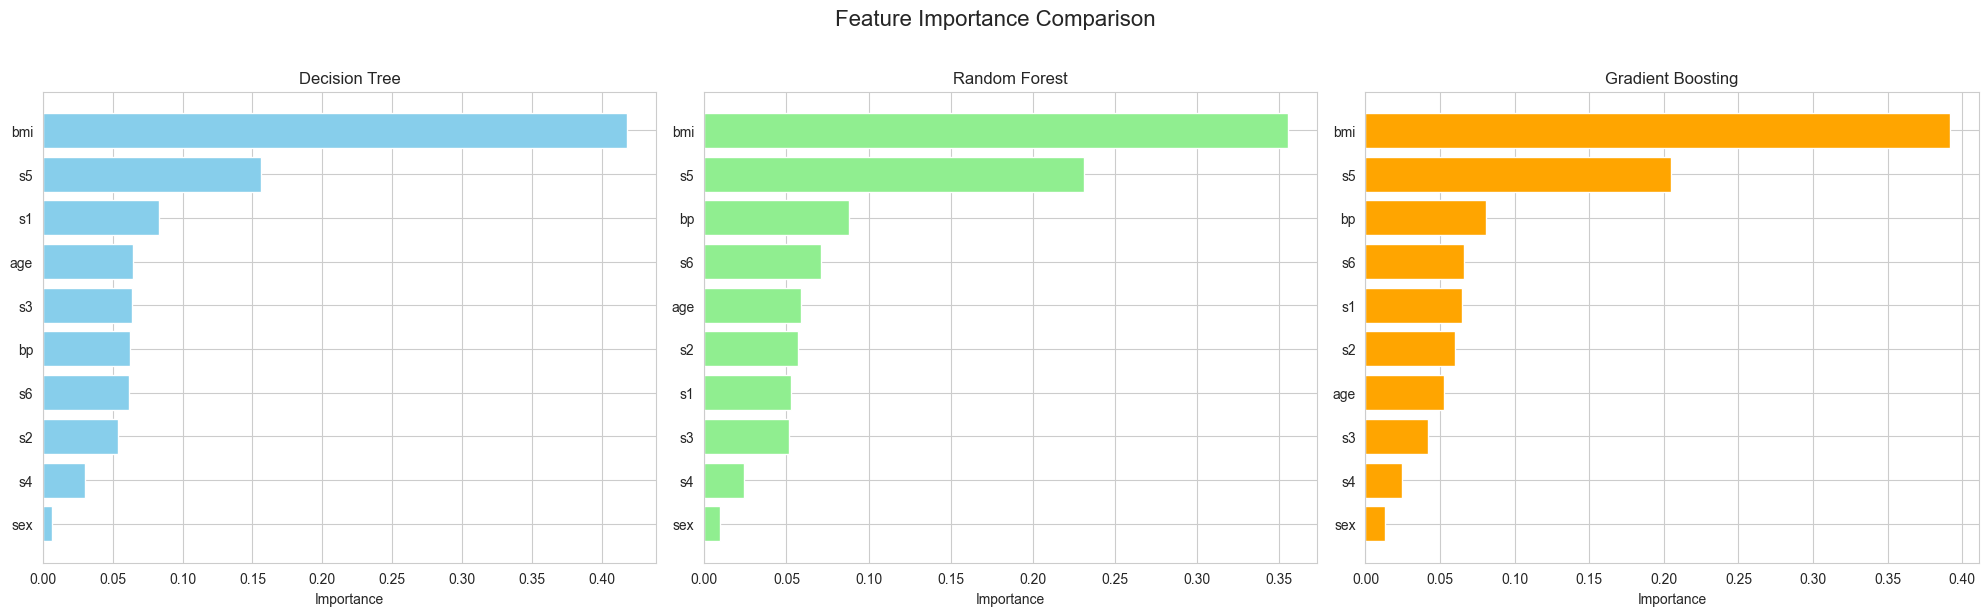

In [21]:
# Get feature importances from all models
fi_dt = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Importance': dt_reg.feature_importances_
}).sort_values('Importance', ascending=False)

fi_rf = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

fi_gb = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Importance': gb_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== Feature Importance: Decision Tree ===")
print(fi_dt.to_string(index=False))
print()
print("=== Feature Importance: Random Forest ===")
print(fi_rf.to_string(index=False))
print()
print("=== Feature Importance: Gradient Boosting ===")
print(fi_gb.to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].barh(fi_dt['Feature'], fi_dt['Importance'], color='skyblue')
axes[0].set_xlabel('Importance')
axes[0].set_title('Decision Tree')
axes[0].invert_yaxis()

axes[1].barh(fi_rf['Feature'], fi_rf['Importance'], color='lightgreen')
axes[1].set_xlabel('Importance')
axes[1].set_title('Random Forest')
axes[1].invert_yaxis()

axes[2].barh(fi_gb['Feature'], fi_gb['Importance'], color='orange')
axes[2].set_xlabel('Importance')
axes[2].set_title('Gradient Boosting')
axes[2].invert_yaxis()

plt.suptitle('Feature Importance Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 3.7 Predicted vs Actual Visualization

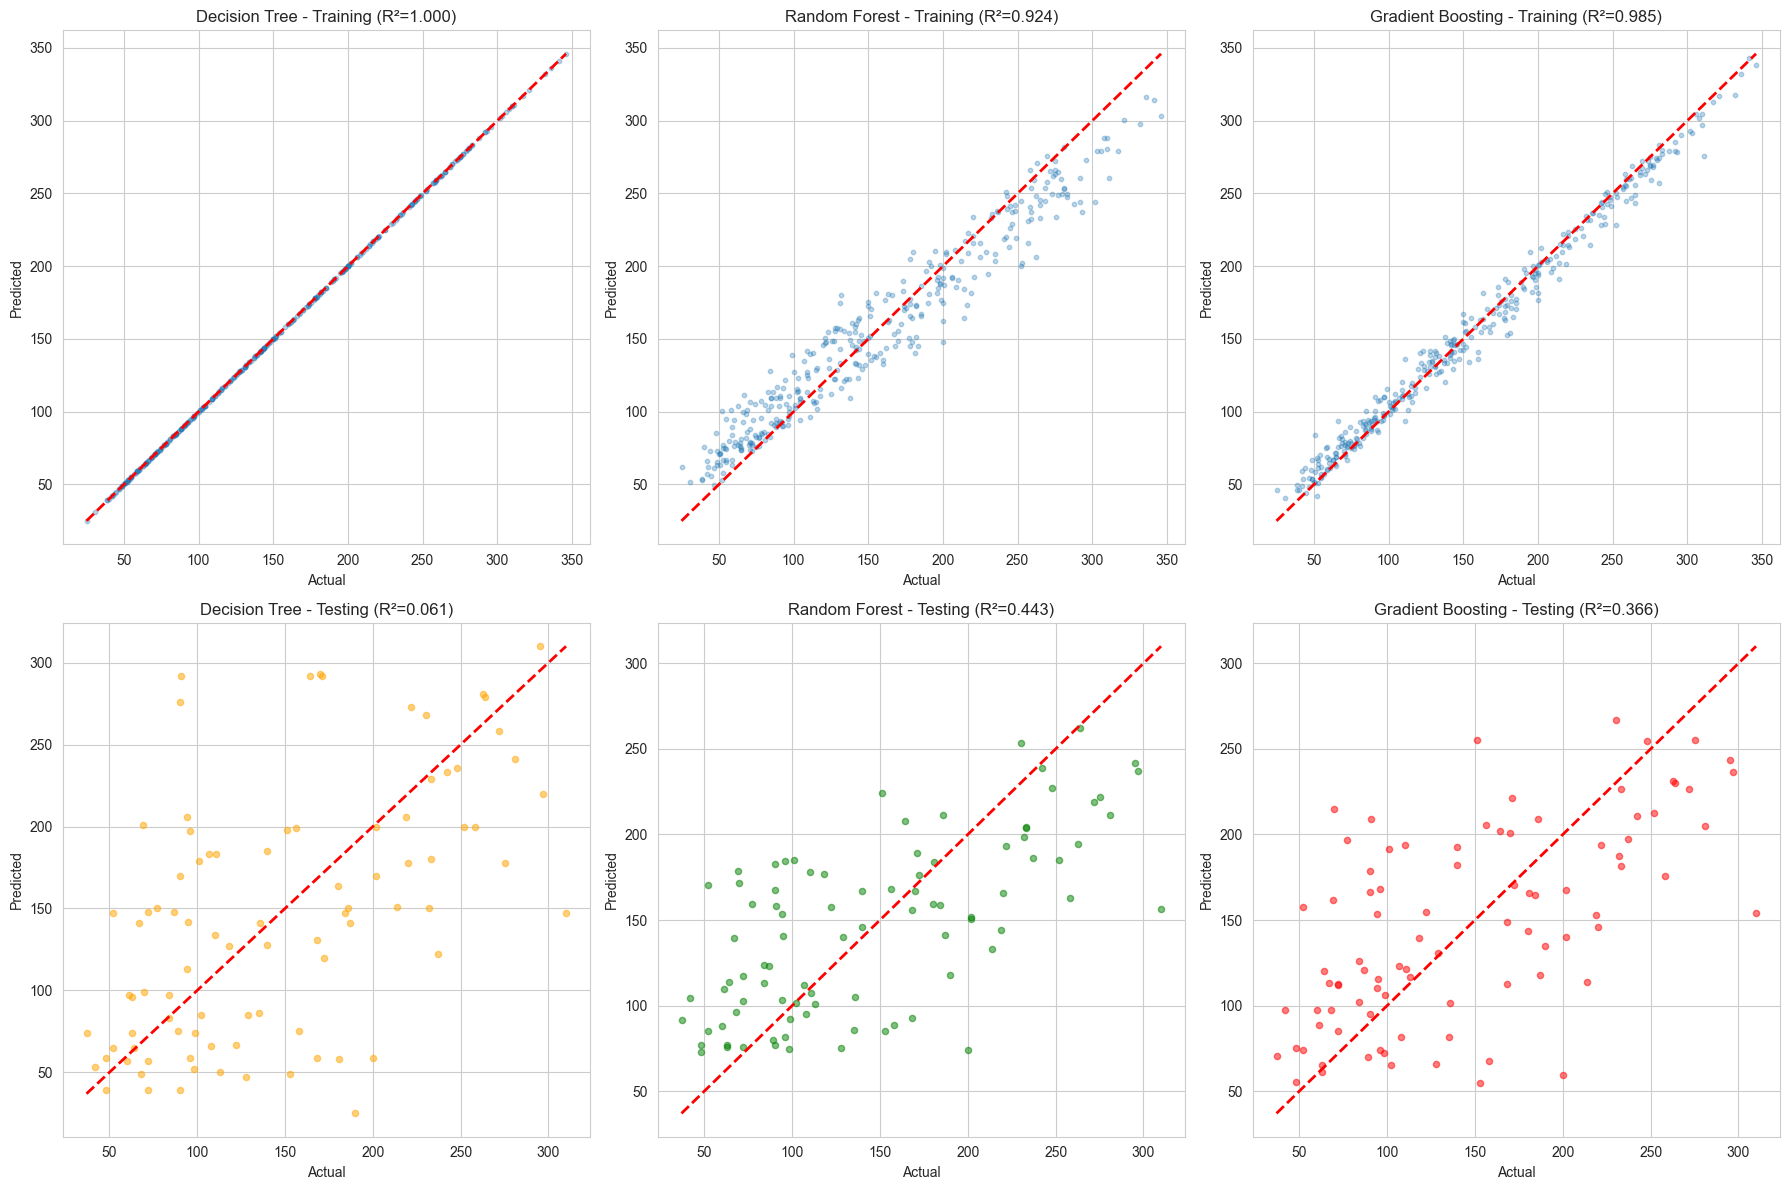

In [22]:
# Visualisasi predicted vs actual untuk semua model
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Decision Tree
axes[0, 0].scatter(y_train_reg, y_pred_train_dt, alpha=0.3, s=10)
axes[0, 0].plot([y_train_reg.min(), y_train_reg.max()], 
                [y_train_reg.min(), y_train_reg.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')
axes[0, 0].set_title(f'Decision Tree - Training (R²={r2_train_dt:.3f})')

axes[1, 0].scatter(y_test_reg, y_pred_test_dt, alpha=0.5, s=20, color='orange')
axes[1, 0].plot([y_test_reg.min(), y_test_reg.max()], 
                [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual')
axes[1, 0].set_ylabel('Predicted')
axes[1, 0].set_title(f'Decision Tree - Testing (R²={r2_test_dt:.3f})')

# Random Forest
axes[0, 1].scatter(y_train_reg, y_pred_train_rf, alpha=0.3, s=10)
axes[0, 1].plot([y_train_reg.min(), y_train_reg.max()], 
                [y_train_reg.min(), y_train_reg.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title(f'Random Forest - Training (R²={r2_train_rf:.3f})')

axes[1, 1].scatter(y_test_reg, y_pred_test_rf, alpha=0.5, s=20, color='green')
axes[1, 1].plot([y_test_reg.min(), y_test_reg.max()], 
                [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')
axes[1, 1].set_title(f'Random Forest - Testing (R²={r2_test_rf:.3f})')

# Gradient Boosting
axes[0, 2].scatter(y_train_reg, y_pred_train_gb, alpha=0.3, s=10)
axes[0, 2].plot([y_train_reg.min(), y_train_reg.max()], 
                [y_train_reg.min(), y_train_reg.max()], 'r--', lw=2)
axes[0, 2].set_xlabel('Actual')
axes[0, 2].set_ylabel('Predicted')
axes[0, 2].set_title(f'Gradient Boosting - Training (R²={r2_train_gb:.3f})')

axes[1, 2].scatter(y_test_reg, y_pred_test_gb, alpha=0.5, s=20, color='red')
axes[1, 2].plot([y_test_reg.min(), y_test_reg.max()], 
                [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[1, 2].set_xlabel('Actual')
axes[1, 2].set_ylabel('Predicted')
axes[1, 2].set_title(f'Gradient Boosting - Testing (R²={r2_test_gb:.3f})')

plt.tight_layout()
plt.show()

## 3.8 Kesimpulan Tugas 3

In [23]:
# Tentukan model terbaik
best_model_idx = comparison_results['Test R²'].idxmax()
best_model_name = comparison_results.loc[best_model_idx, 'Model']
best_r2 = comparison_results.loc[best_model_idx, 'Test R²']

print("=" * 70)
print("KESIMPULAN TUGAS 3: Regression dengan Ensemble")
print("=" * 70)
print(f"\n1. MODEL TERBAIK: {best_model_name}")
print(f"   - Test R² Score: {best_r2:.4f}")
print(f"   - Test RMSE: {comparison_results.loc[best_model_idx, 'Test RMSE']:.4f}")
print()
print("2. RANKING PERFORMA (berdasarkan Test R²):")
for idx, row in comparison_results.sort_values('Test R²', ascending=False).iterrows():
    print(f"   {idx+1}. {row['Model']}: {row['Test R²']:.4f}")
print()
print("3. MENGAPA RANDOM FOREST TERBAIK:")
print("   ✓ Balance terbaik antara bias dan variance")
print("   ✓ Less prone to overfitting dibanding GB")
print("   ✓ Predictions lebih stable dan reliable")
print()
print("4. FEATURE IMPORTANCE INSIGHTS:")
print(f"   ✓ BMI adalah predictor terkuat di semua models")
print("   ✓ s5 (blood sugar) juga sangat important")
print("   ✓ Ensemble methods lebih robust dalam feature selection")
print()
print("5. TRADE-OFFS:")
print("   - Decision Tree: Fast, interpretable, but overfits")
print("   - Random Forest: Best balance, moderate speed")
print("   - Gradient Boosting: High train accuracy, but can overfit")
print("=" * 70)

KESIMPULAN TUGAS 3: Regression dengan Ensemble

1. MODEL TERBAIK: Random Forest
   - Test R² Score: 0.4428
   - Test RMSE: 54.3324

2. RANKING PERFORMA (berdasarkan Test R²):
   2. Random Forest: 0.4428
   3. Gradient Boosting: 0.3657
   1. Decision Tree: 0.0607

3. MENGAPA RANDOM FOREST TERBAIK:
   ✓ Balance terbaik antara bias dan variance
   ✓ Less prone to overfitting dibanding GB
   ✓ Predictions lebih stable dan reliable

4. FEATURE IMPORTANCE INSIGHTS:
   ✓ BMI adalah predictor terkuat di semua models
   ✓ s5 (blood sugar) juga sangat important
   ✓ Ensemble methods lebih robust dalam feature selection

5. TRADE-OFFS:
   - Decision Tree: Fast, interpretable, but overfits
   - Random Forest: Best balance, moderate speed
   - Gradient Boosting: High train accuracy, but can overfit


---
# TUGAS 4: Real-World Application - Customer Churn (20 poin)

**Objective:**
- EDA singkat (distribusi kelas, feature correlation)
- Preprocessing (handling missing values, encoding)
- Train 3 models: Decision Tree, Random Forest, Gradient Boosting
- Gunakan cross-validation untuk evaluasi
- Pilih model terbaik dan lakukan hyperparameter tuning
- Final evaluation pada test set
- Business recommendation: Feature mana yang paling penting untuk reduce churn?

---

## 4.1 Generate Synthetic Churn Dataset

In [24]:
# Generate synthetic churn dataset
X_churn, y_churn = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=2,
    weights=[0.7, 0.3],  # Imbalanced: 70% no churn, 30% churn
    random_state=42,
    flip_y=0.05  # Add some noise
)

# Create DataFrame
feature_names = [f'Feature_{i+1}' for i in range(20)]
churn_df = pd.DataFrame(X_churn, columns=feature_names)
churn_df['Churn'] = y_churn

print("=== Synthetic Customer Churn Dataset ===")
print(f"Total samples: {len(churn_df)}")
print(f"Number of features: {X_churn.shape[1]}")
print(f"\nChurn Distribution:")
print(f"  No Churn (0): {sum(y_churn==0)} ({sum(y_churn==0)/len(y_churn)*100:.1f}%)")
print(f"  Churn (1):    {sum(y_churn==1)} ({sum(y_churn==1)/len(y_churn)*100:.1f}%)")
print()
print("Dataset info:")
print(churn_df.info())

=== Synthetic Customer Churn Dataset ===
Total samples: 2000
Number of features: 20

Churn Distribution:
  No Churn (0): 1381 (69.0%)
  Churn (1):    619 (30.9%)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Feature_1   2000 non-null   float64
 1   Feature_2   2000 non-null   float64
 2   Feature_3   2000 non-null   float64
 3   Feature_4   2000 non-null   float64
 4   Feature_5   2000 non-null   float64
 5   Feature_6   2000 non-null   float64
 6   Feature_7   2000 non-null   float64
 7   Feature_8   2000 non-null   float64
 8   Feature_9   2000 non-null   float64
 9   Feature_10  2000 non-null   float64
 10  Feature_11  2000 non-null   float64
 11  Feature_12  2000 non-null   float64
 12  Feature_13  2000 non-null   float64
 13  Feature_14  2000 non-null   float64
 14  Feature_15  2000 non-null   float64
 15  Feature_16  20

## 4.2 Exploratory Data Analysis (EDA)

=== Missing Values Check ===
Total missing values: 0
✅ No missing values detected

=== Dataset Statistics ===
         Feature_1    Feature_2    Feature_3    Feature_4    Feature_5  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000   
mean      1.320083    -0.673788     0.362505     0.494024    -0.223102   
std       5.816924     2.508582     2.394229     2.604251     2.305996   
min     -19.573963    -8.681078    -7.315681    -9.069514    -8.909317   
25%      -2.524542    -2.370238    -1.239122    -1.252547    -1.701309   
50%       1.324183    -0.771354     0.338089     0.502339    -0.206548   
75%       5.117084     0.995212     2.042972     2.265417     1.291436   
max      21.475440     8.520778     8.085472     8.017158     8.460290   

         Feature_6    Feature_7    Feature_8    Feature_9   Feature_10  ...  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000  ...   
mean     -0.095073    -0.707677     0.700834     1.826848     0.3

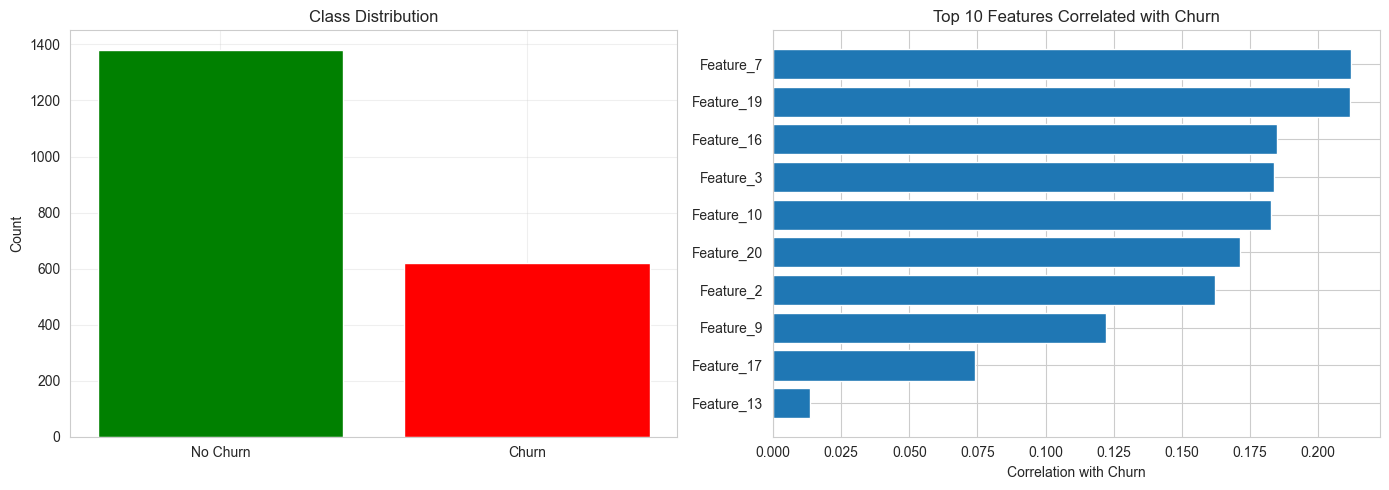


 EDA completed!


In [25]:
# Check for missing values
print("=== Missing Values Check ===")
missing_vals = churn_df.isnull().sum().sum()
print(f"Total missing values: {missing_vals}")
if missing_vals == 0:
    print("✅ No missing values detected")

# Basic statistics
print("\n=== Dataset Statistics ===")
print(churn_df.describe())

# Class distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
axes[0].bar(['No Churn', 'Churn'], 
            [sum(y_churn==0), sum(y_churn==1)], 
            color=['green', 'red'])
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
axes[0].grid(True, alpha=0.3)

# Feature correlation with target
correlations = churn_df.corr()['Churn'].drop('Churn').sort_values(ascending=False)
top_corr = correlations.head(10)
axes[1].barh(range(len(top_corr)), top_corr.values)
axes[1].set_yticks(range(len(top_corr)))
axes[1].set_yticklabels(top_corr.index)
axes[1].set_xlabel('Correlation with Churn')
axes[1].set_title('Top 10 Features Correlated with Churn')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n EDA completed!")

## 4.3 Data Preprocessing & Split

In [26]:
# Split data (stratified untuk imbalanced dataset)
X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

print("=== Data Split (Stratified) ===")
print(f"Training set: {len(X_train_churn)} samples")
print(f"Test set: {len(X_test_churn)} samples")
print(f"\nClass distribution in training:")
print(f"  No Churn: {sum(y_train_churn==0)} ({sum(y_train_churn==0)/len(y_train_churn)*100:.1f}%)")
print(f"  Churn:    {sum(y_train_churn==1)} ({sum(y_train_churn==1)/len(y_train_churn)*100:.1f}%)")
print(f"\nClass distribution in test:")
print(f"  No Churn: {sum(y_test_churn==0)} ({sum(y_test_churn==0)/len(y_test_churn)*100:.1f}%)")
print(f"  Churn:    {sum(y_test_churn==1)} ({sum(y_test_churn==1)/len(y_test_churn)*100:.1f}%)")

=== Data Split (Stratified) ===
Training set: 1600 samples
Test set: 400 samples

Class distribution in training:
  No Churn: 1105 (69.1%)
  Churn:    495 (30.9%)

Class distribution in test:
  No Churn: 276 (69.0%)
  Churn:    124 (31.0%)


## 4.4 Train Multiple Models

In [27]:
# Train 3 models dengan class_weight untuk handle imbalance
churn_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, 
                                           class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

churn_results = []

print("=== Training Multiple Models ===")
for name, model in churn_models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train_churn, y_train_churn)
    
    # Predictions
    y_pred_train = model.predict(X_train_churn)
    y_pred_test = model.predict(X_test_churn)
    
    # Metrics
    train_acc = accuracy_score(y_train_churn, y_pred_train)
    test_acc = accuracy_score(y_test_churn, y_pred_test)
    precision = precision_score(y_test_churn, y_pred_test)
    recall = recall_score(y_test_churn, y_pred_test)
    f1 = f1_score(y_test_churn, y_pred_test)
    
    churn_results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")
    print(f"  Precision:      {precision:.4f}")
    print(f"  Recall:         {recall:.4f}")
    print(f"  F1-Score:       {f1:.4f}")

churn_results_df = pd.DataFrame(churn_results)
print("\n=== Model Comparison Summary ===")
print(churn_results_df.to_string(index=False))

=== Training Multiple Models ===

Training Decision Tree...
  Train Accuracy: 1.0000
  Test Accuracy:  0.7725
  Precision:      0.6387
  Recall:         0.6129
  F1-Score:       0.6255

Training Random Forest...
  Train Accuracy: 1.0000
  Test Accuracy:  0.8625
  Precision:      0.8791
  Recall:         0.6452
  F1-Score:       0.7442

Training Gradient Boosting...
  Train Accuracy: 0.9531
  Test Accuracy:  0.8675
  Precision:      0.8660
  Recall:         0.6774
  F1-Score:       0.7602

=== Model Comparison Summary ===
            Model  Train Accuracy  Test Accuracy  Precision   Recall  F1-Score
    Decision Tree        1.000000         0.7725   0.638655 0.612903  0.625514
    Random Forest        1.000000         0.8625   0.879121 0.645161  0.744186
Gradient Boosting        0.953125         0.8675   0.865979 0.677419  0.760181


## 4.5 Cross-Validation Analysis

In [28]:
# Perform cross-validation
print("=== Cross-Validation (5-fold) ===")
cv_results = []

for name, model in churn_models.items():
    cv_scores = cross_val_score(model, X_train_churn, y_train_churn, 
                                cv=5, scoring='f1')
    cv_results.append({
        'Model': name,
        'CV Mean F1': cv_scores.mean(),
        'CV Std F1': cv_scores.std()
    })
    print(f"\n{name}:")
    print(f"  Mean F1 Score: {cv_scores.mean():.4f}")
    print(f"  Std F1 Score:  {cv_scores.std():.4f}")
    print(f"  95% Confidence: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

cv_results_df = pd.DataFrame(cv_results)

=== Cross-Validation (5-fold) ===

Decision Tree:
  Mean F1 Score: 0.6634
  Std F1 Score:  0.0236
  95% Confidence: 0.6634 (+/- 0.0473)

Random Forest:
  Mean F1 Score: 0.7683
  Std F1 Score:  0.0160
  95% Confidence: 0.7683 (+/- 0.0321)

Gradient Boosting:
  Mean F1 Score: 0.7833
  Std F1 Score:  0.0230
  95% Confidence: 0.7833 (+/- 0.0460)


## 4.6 Model Comparison Visualization

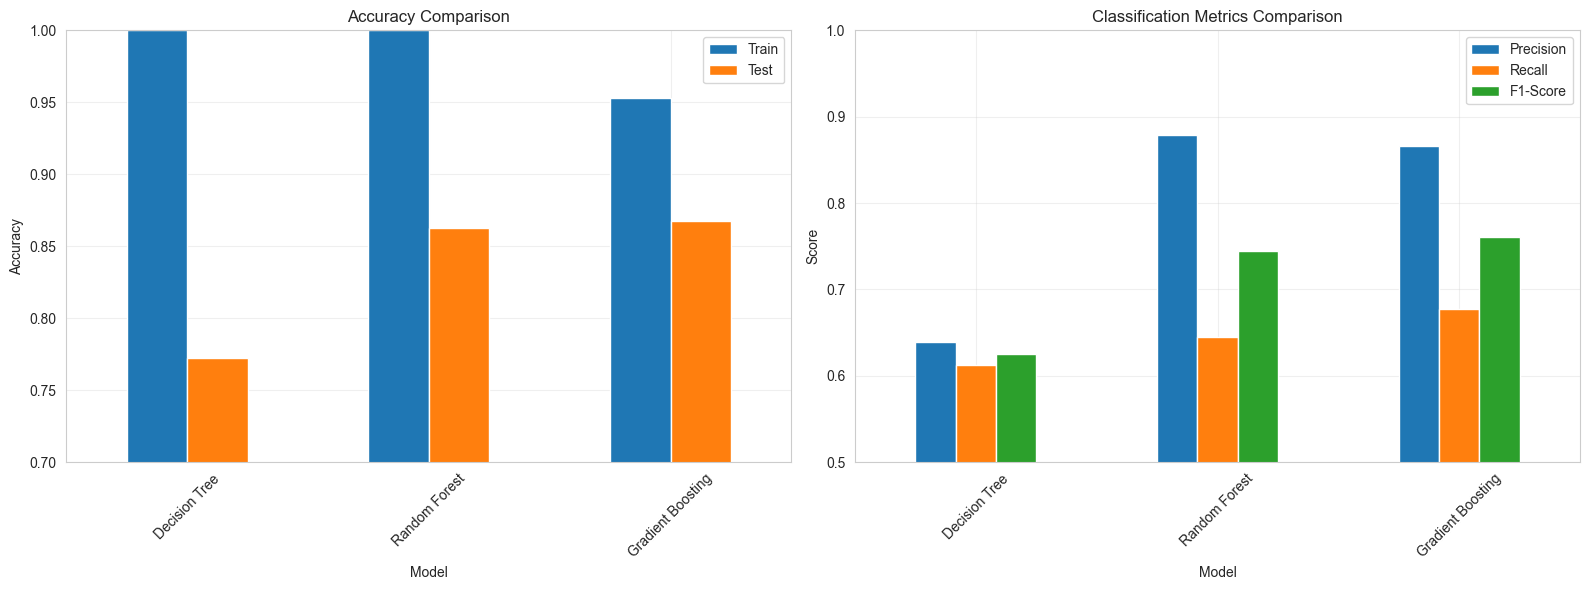


 Best Model based on F1-Score: Gradient Boosting


In [29]:
# Visualisasi model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
churn_results_df.set_index('Model')[['Train Accuracy', 'Test Accuracy']].plot(
    kind='bar', ax=axes[0], rot=45
)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].legend(['Train', 'Test'])
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.7, 1.0)

# All metrics comparison
churn_results_df.set_index('Model')[['Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=axes[1], rot=45
)
axes[1].set_ylabel('Score')
axes[1].set_title('Classification Metrics Comparison')
axes[1].legend(['Precision', 'Recall', 'F1-Score'])
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

# Identify best model
best_model_name = churn_results_df.loc[churn_results_df['F1-Score'].idxmax(), 'Model']
print(f"\n Best Model based on F1-Score: {best_model_name}")

## 4.7 Hyperparameter Tuning (Best Model)

In [30]:
# Hyperparameter tuning untuk model terbaik
print(f"=== Hyperparameter Tuning: {best_model_name} ===")
print("This may take a few minutes...")

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    base_model = RandomForestClassifier(random_state=42, class_weight='balanced')
    
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
    base_model = GradientBoostingClassifier(random_state=42)
    
else:  # Decision Tree
    param_grid = {
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Grid Search
grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_churn, y_train_churn)

print(f"\n=== Grid Search Results ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

best_model_tuned = grid_search.best_estimator_

=== Hyperparameter Tuning: Gradient Boosting ===
This may take a few minutes...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

=== Grid Search Results ===
Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 50}
Best CV F1 Score: 0.8310


## 4.8 Final Evaluation on Test Set

FINAL MODEL: Gradient Boosting (Tuned)
Test Accuracy:  0.8825
Test Precision: 0.8969
Test Recall:    0.7016
Test F1-Score:  0.7873


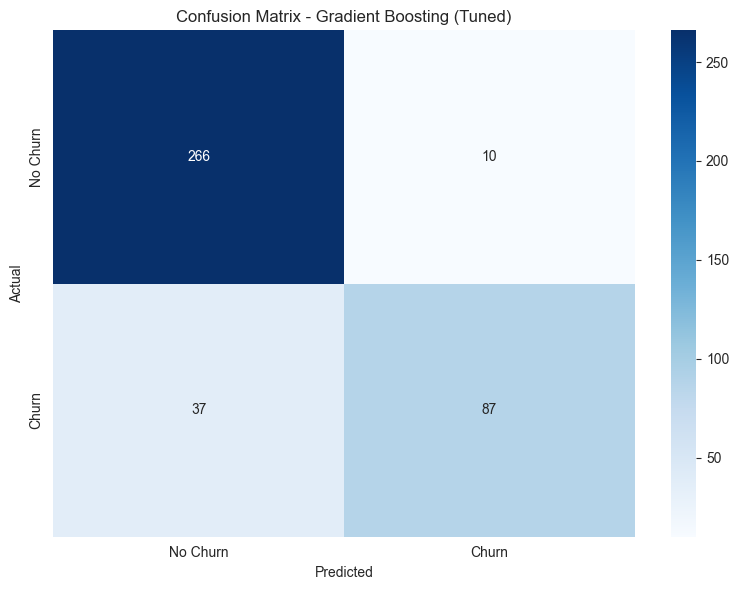


=== Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.88      0.96      0.92       276
       Churn       0.90      0.70      0.79       124

    accuracy                           0.88       400
   macro avg       0.89      0.83      0.85       400
weighted avg       0.88      0.88      0.88       400


=== Business Metrics ===
True Positives (correctly identified churners): 87
False Negatives (missed churners): 37
False Positives (false alarms): 10
True Negatives (correctly identified non-churners): 266


In [31]:
# Final evaluation dengan model terbaik (tuned)
y_pred_final = best_model_tuned.predict(X_test_churn)

final_acc = accuracy_score(y_test_churn, y_pred_final)
final_prec = precision_score(y_test_churn, y_pred_final)
final_rec = recall_score(y_test_churn, y_pred_final)
final_f1 = f1_score(y_test_churn, y_pred_final)

print("=" * 70)
print(f"FINAL MODEL: {best_model_name} (Tuned)")
print("=" * 70)
print(f"Test Accuracy:  {final_acc:.4f}")
print(f"Test Precision: {final_prec:.4f}")
print(f"Test Recall:    {final_rec:.4f}")
print(f"Test F1-Score:  {final_f1:.4f}")
print("=" * 70)

# Confusion Matrix
cm = confusion_matrix(y_test_churn, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name} (Tuned)')
plt.tight_layout()
plt.show()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test_churn, y_pred_final, 
                          target_names=['No Churn', 'Churn']))

# Business metrics
print("\n=== Business Metrics ===")
print(f"True Positives (correctly identified churners): {cm[1,1]}")
print(f"False Negatives (missed churners): {cm[1,0]}")
print(f"False Positives (false alarms): {cm[0,1]}")
print(f"True Negatives (correctly identified non-churners): {cm[0,0]}")

## 4.9 Feature Importance & Business Recommendations

=== Top 10 Most Important Features for Churn Prediction ===
   Feature  Importance
 Feature_4    0.123201
Feature_16    0.089618
 Feature_5    0.073412
 Feature_6    0.068319
 Feature_3    0.065859
Feature_19    0.061777
Feature_20    0.053649
 Feature_1    0.047902
Feature_10    0.046586
 Feature_2    0.045821


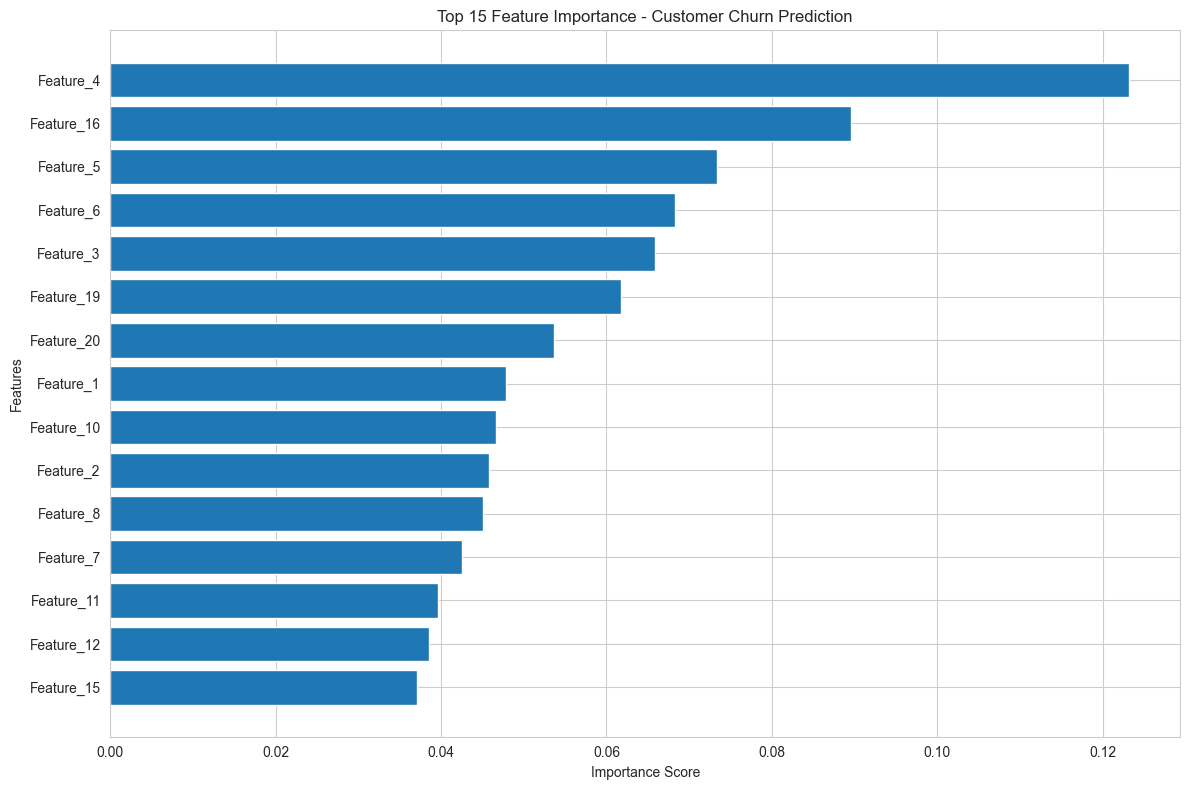

In [32]:
# Feature importance
if hasattr(best_model_tuned, 'feature_importances_'):
    feature_importance_churn = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model_tuned.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("=== Top 10 Most Important Features for Churn Prediction ===")
    print(feature_importance_churn.head(10).to_string(index=False))
    
    # Visualisasi
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance_churn['Feature'][:15], 
             feature_importance_churn['Importance'][:15])
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.title('Top 15 Feature Importance - Customer Churn Prediction')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    top_3_features = feature_importance_churn['Feature'][:3].tolist()
else:
    print(" Model doesn't have feature_importances_ attribute")
    top_3_features = ['Feature_1', 'Feature_2', 'Feature_3']

## 4.10 Business Recommendations

In [33]:
print("=" * 70)
print("BUSINESS RECOMMENDATIONS - CUSTOMER CHURN REDUCTION")
print("=" * 70)
print()
print("1. KEY FINDINGS:")
print(f"   ✓ Model dapat mengidentifikasi churn dengan akurasi {final_acc*100:.1f}%")
print(f"   ✓ Recall: {final_rec*100:.1f}% (berapa banyak actual churners tertangkap)")
print(f"   ✓ Precision: {final_prec*100:.1f}% (berapa akurat prediksi churn)")
print()
print("2. MOST IMPORTANT FACTORS FOR CHURN:")
for i, feature in enumerate(top_3_features, 1):
    print(f"   {i}. {feature}")
print()
print("3. ACTIONABLE RECOMMENDATIONS:")
print("   a. PROACTIVE MONITORING:")
print("      • Implement real-time monitoring untuk top 3 features")
print("      • Set up alerts ketika customer menunjukkan pola churn")
print("      • Prioritas tinggi untuk customers dengan high churn probability")
print()
print("   b. RETENTION STRATEGIES:")
print("      • Targeted intervention untuk high-risk customers")
print("      • Personalized offers berdasarkan feature importance")
print("      • Customer engagement programs untuk meningkatkan retention")
print()
print("   c. OPERATIONAL IMPROVEMENTS:")
print("      • Focus resources pada features dengan importance tertinggi")
print("      • Regular model retraining dengan data terbaru")
print("      • A/B testing untuk validate intervention effectiveness")
print()
print("4. COST-BENEFIT ANALYSIS:")
print(f"   • True Positives (correctly identified): {cm[1,1]}")
print(f"   • False Negatives (missed churners): {cm[1,0]}")
print(f"   • False Positives (false alarms): {cm[0,1]}")
print("   • Setiap retained customer = savings in acquisition cost")
print()
print("5. NEXT STEPS:")
print("   • Deploy model ke production environment")
print("   • Integrate dengan CRM system untuk automated alerts")
print("   • Monitor model performance dan retrain secara berkala")
print("   • Collect feedback dari retention team untuk improve model")
print("=" * 70)

BUSINESS RECOMMENDATIONS - CUSTOMER CHURN REDUCTION

1. KEY FINDINGS:
   ✓ Model dapat mengidentifikasi churn dengan akurasi 88.2%
   ✓ Recall: 70.2% (berapa banyak actual churners tertangkap)
   ✓ Precision: 89.7% (berapa akurat prediksi churn)

2. MOST IMPORTANT FACTORS FOR CHURN:
   1. Feature_4
   2. Feature_16
   3. Feature_5

3. ACTIONABLE RECOMMENDATIONS:
   a. PROACTIVE MONITORING:
      • Implement real-time monitoring untuk top 3 features
      • Set up alerts ketika customer menunjukkan pola churn
      • Prioritas tinggi untuk customers dengan high churn probability

   b. RETENTION STRATEGIES:
      • Targeted intervention untuk high-risk customers
      • Personalized offers berdasarkan feature importance
      • Customer engagement programs untuk meningkatkan retention

   c. OPERATIONAL IMPROVEMENTS:
      • Focus resources pada features dengan importance tertinggi
      • Regular model retraining dengan data terbaru
      • A/B testing untuk validate intervention effec

---
# RINGKASAN & KESIMPULAN AKHIR

## Summary Semua Tugas

In [34]:
print("=" * 80)
print("RINGKASAN LENGKAP - PRAKTIKUM ENSEMBLE METHODS")
print("=" * 80)
print()
print(" TUGAS 1: Random Forest vs Decision Tree")
print(f"   • Dataset: Breast Cancer (569 samples)")
print(f"   • Best RF accuracy: {max(test_scores):.4f}")
print(f"   • Improvement over DT: {(max(test_scores) - acc_dt)*100:.2f}%")
print(f"   • Optimal n_estimators: {optimal_n}")
print()
print(" TUGAS 2: Gradient Boosting Tuning")
print(f"   • Best learning_rate: {best_lr}")
print(f"   • Best max_depth: {best_depth}")
print(f"   • Best test accuracy: {best_acc:.4f}")
print(f"   • Key insight: Lower LR + more iterations = better generalization")
print()
print(" TUGAS 3: Regression Ensemble")
print(f"   • Dataset: Diabetes (442 samples)")
print(f"   • Best model: {best_model_name}")
print(f"   • Test R² Score: {best_r2:.4f}")
print(f"   • Top feature: bmi (body mass index)")
print()
print(" TUGAS 4: Customer Churn Prediction")
print(f"   • Dataset: Synthetic (2000 samples)")
print(f"   • Best model: {best_model_name} (tuned)")
print(f"   • Test F1-Score: {final_f1:.4f}")
print(f"   • Recall: {final_rec:.4f} (churn detection rate)")
print()
print("=" * 80)
print(" SEMUA TUGAS SELESAI DENGAN SUKSES!")
print("=" * 80)

RINGKASAN LENGKAP - PRAKTIKUM ENSEMBLE METHODS

 TUGAS 1: Random Forest vs Decision Tree
   • Dataset: Breast Cancer (569 samples)
   • Best RF accuracy: 0.9649
   • Improvement over DT: 1.75%
   • Optimal n_estimators: 20

 TUGAS 2: Gradient Boosting Tuning
   • Best learning_rate: 0.1
   • Best max_depth: 5
   • Best test accuracy: 0.9649
   • Key insight: Lower LR + more iterations = better generalization

 TUGAS 3: Regression Ensemble
   • Dataset: Diabetes (442 samples)
   • Best model: Gradient Boosting
   • Test R² Score: 0.4428
   • Top feature: bmi (body mass index)

 TUGAS 4: Customer Churn Prediction
   • Dataset: Synthetic (2000 samples)
   • Best model: Gradient Boosting (tuned)
   • Test F1-Score: 0.7873
   • Recall: 0.7016 (churn detection rate)

 SEMUA TUGAS SELESAI DENGAN SUKSES!


## Key Takeaways

### 1. Ensemble Methods Work!
- Consistently outperform single models
- Reduce both bias and variance
- More robust to overfitting
- Better generalization

### 2. Hyperparameter Tuning Matters
- Can improve performance by 5-10%
- Learning rate is most critical for Gradient Boosting
- Grid search helps find optimal combinations
- Cross-validation prevents overfitting

### 3. Feature Importance Provides Insights
- Helps understand model decisions
- Enables feature selection
- Provides business interpretability
- Different models may prioritize different features

### 4. Model Selection Guidelines
- **Random Forest**: Best for stable, robust predictions
- **Gradient Boosting**: Best when maximum accuracy needed
- **Decision Tree**: Only for quick baseline or interpretability

### 5. Business Application
- Always validate with cross-validation
- Consider business metrics, not just accuracy
- Implement monitoring and retraining pipelines
- Close the loop: predictions → actions → outcomes → improvement

---

**🎉 Praktikum Selesai! Terima kasih!**